In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Install pvlib if not present for astronomical solar position calculation
try:
    import pvlib
except ImportError:
    !pip install -q pvlib
    import pvlib

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

In [2]:
# Data search paths (handles Google Drive, Colab local, and workspace environments)
hdf5_paths = [
    "/home/haseebumer/content/data/2017_2019_images_pv_processed.hdf5",
]

hdf5_path = None
for p in hdf5_paths:
    if os.path.exists(p):
        hdf5_path = p
        break

# Extracted directory fallback
data_dir = (
    "/home/haseebumer/content/data/extracted/" if os.path.exists("/home/haseebumer/content/data/extracted/") else "./"
)

if hdf5_path:
    print(f"Loading directly from HDF5: {hdf5_path}")
    f_h5 = h5py.File(hdf5_path, "r")
    trainval_images = f_h5["trainval"]["images_log"]
    trainval_pv = np.array(f_h5["trainval"]["pv_log"])
    test_images = f_h5["test"]["images_log"]
    test_pv = np.array(f_h5["test"]["pv_log"])
else:
    print("Loading from extracted .npy files...")
    # Try defisheyed first, then processed
    tv_img_p = os.path.join(data_dir, "trainval_images_defisheye.npy")
    if not os.path.exists(tv_img_p):
        tv_img_p = os.path.join(data_dir, "trainval_images_log.npy")
    trainval_images = np.load(tv_img_p, mmap_mode="r")
    trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy"))

    te_img_p = os.path.join(data_dir, "test_images_defisheye.npy")
    if not os.path.exists(te_img_p):
        te_img_p = os.path.join(data_dir, "test_images_log.npy")
    test_images = np.load(te_img_p, mmap_mode="r")
    test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy"))

# Load timestamps
for t_path in [
    "/home/haseebumer/content/data/times_trainval.npy",
    "/home/haseebumer/content/drive/MyDrive/solar_data/times_trainval.npy",
    "times_trainval.npy",
]:
    if os.path.exists(t_path):
        trainval_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    trainval_times = None

for t_path in [
    "/home/haseebumer/content/data/times_test.npy",
    "/home/haseebumer/content/drive/MyDrive/solar_data/times_test.npy",
    "times_test.npy",
]:
    if os.path.exists(t_path):
        test_times = pd.to_datetime(np.load(t_path, allow_pickle=True))
        break
else:
    test_times = None

print(f"Train/Val Images: {trainval_images.shape} | PV: {trainval_pv.shape}")
print(f"Test Images:     {test_images.shape} | PV: {test_pv.shape}")
if trainval_times is not None:
    print(f"Train/Val Dates:  {trainval_times[0]} to {trainval_times[-1]}")
if test_times is not None:
    print(f"Test Dates:       {test_times[0]} to {test_times[-1]}")

Loading directly from HDF5: /home/haseebumer/content/data/2017_2019_images_pv_processed.hdf5
Train/Val Images: (349372, 64, 64, 3) | PV: (349372,)
Test Images:     (14003, 64, 64, 3) | PV: (14003,)
Train/Val Dates:  2017-03-09 06:47:00 to 2019-10-26 17:59:20
Test Dates:       2017-09-15 07:11:00 to 2019-10-19 18:15:30


In [3]:
# Show a random sample from all images

rng = np.random.default_rng(np.random.choice(range(1, 10000)))

# Randomly choose train/val or test
split = rng.choice(["trainval", "test"])

if split == "trainval":
    idx = rng.integers(0, len(trainval_images))
    image = np.array(trainval_images[idx])
    pv = trainval_pv[idx]
    timestamp = trainval_times[idx] if trainval_times is not None else None
else:
    idx = rng.integers(0, len(test_images))
    image = np.array(test_images[idx])
    pv = test_pv[idx]
    timestamp = test_times[idx] if test_times is not None else None

print("Split:", split)
print("Random index:", idx)
print("Image shape:", image.shape)
print("PV value:", pv)
print("Timestamp:", timestamp)
print("Image array:")
print(image)

Split: test
Random index: 91
Image shape: (64, 64, 3)
PV value: 7.700133999
Timestamp: 2017-09-15 08:42:00
Image array:
[[[  0   0   0]
  [  0   0   0]
  [126 126 127]
  ...
  [  2   0   1]
  [  2   0   2]
  [  2   0   2]]

 [[  0   0   0]
  [  0   0   0]
  [  1   1   1]
  ...
  [  2   0   0]
  [  3   0   2]
  [  3   0   2]]

 [[  0   0   0]
  [  0   0   0]
  [  1   1   2]
  ...
  [  2   0   2]
  [  3   0   2]
  [  3   0   2]]

 ...

 [[  0   0   0]
  [  1   1   2]
  [  0   1   2]
  ...
  [  1   0   2]
  [  1   0   2]
  [  1   0   2]]

 [[  0   0   0]
  [  1   1   2]
  [  0   0   0]
  ...
  [  1   0   2]
  [  1   0   2]
  [  1   0   2]]

 [[  0   0   0]
  [  1   0   2]
  [  1   1   2]
  ...
  [  1   0   2]
  [  1   0   2]
  [  1   0   2]]]


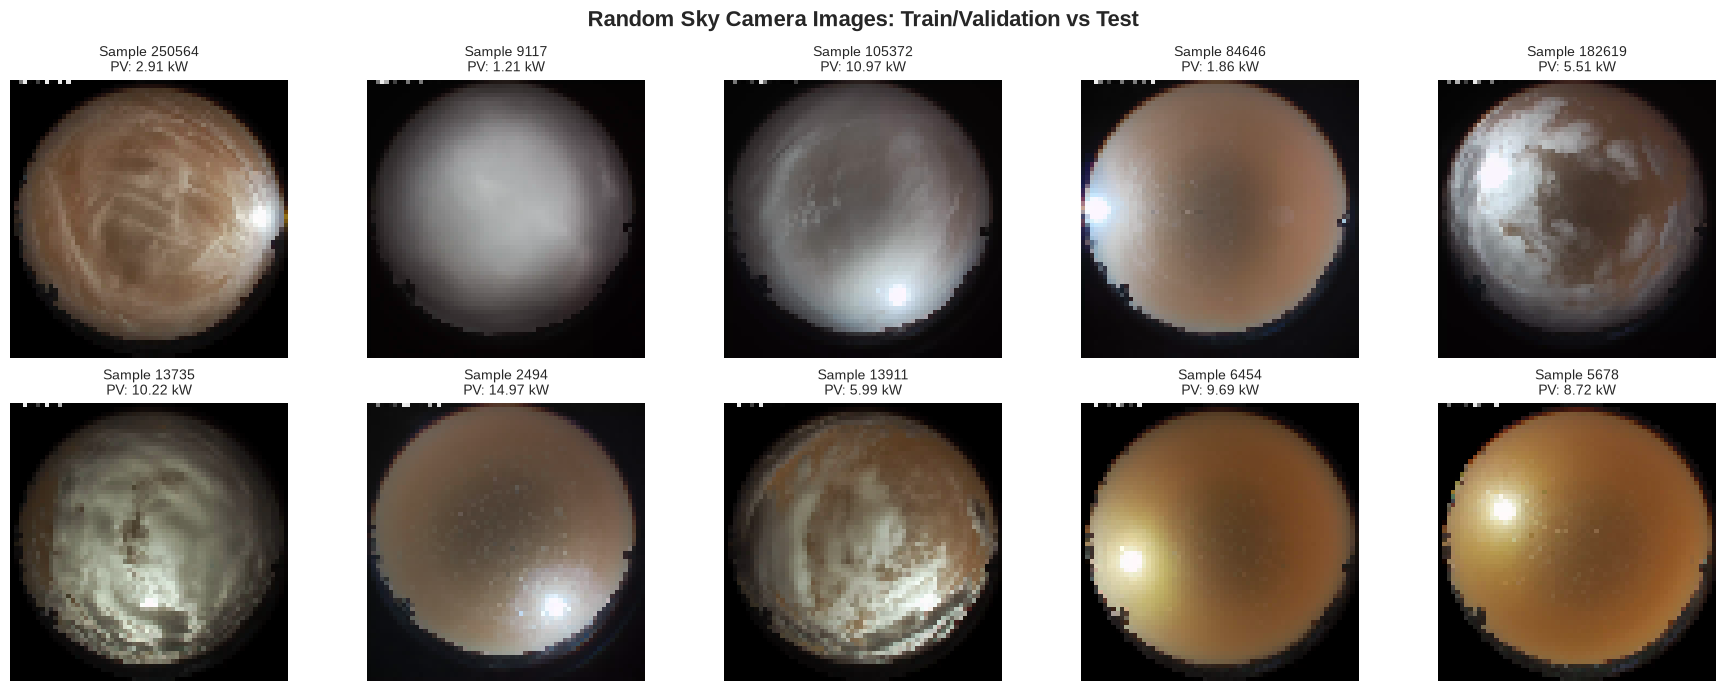

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def format_img(img):
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))

    if img.max() > 1.0 and img.dtype != np.uint8:
        img = img / 255.0

    return img


num_samples = 5

train_indices = np.random.choice(len(trainval_images), size=num_samples, replace=False)

test_indices = np.random.choice(len(test_images), size=num_samples, replace=False)

fig, axes = plt.subplots(2, num_samples, figsize=(18, 7))

fig.suptitle(
    "Random Sky Camera Images: Train/Validation vs Test", fontsize=16, fontweight="bold"
)

for col, idx in enumerate(train_indices):

    axes[0, col].imshow(format_img(trainval_images[idx]))

    pv_val = trainval_pv[idx]

    axes[0, col].set_title(f"Sample {idx}\nPV: {pv_val:.2f} kW", fontsize=10)

    axes[0, col].axis("off")


for col, idx in enumerate(test_indices):

    axes[1, col].imshow(format_img(test_images[idx]))

    pv_val = test_pv[idx]

    axes[1, col].set_title(f"Sample {idx}\nPV: {pv_val:.2f} kW", fontsize=10)

    axes[1, col].axis("off")


axes[0, 0].set_ylabel("Train / Validation", fontsize=12, fontweight="bold")

axes[1, 0].set_ylabel("Test", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## PV Time Series EDA


In [5]:
pv_summary = pd.DataFrame(
    {
        "Train/Val": pd.Series(trainval_pv.flatten()).describe(),
        "Test": pd.Series(test_pv.flatten()).describe(),
    }
)
print(pv_summary)

           Train/Val          Test
count  349372.000000  14003.000000
mean       13.277489     12.588559
std         7.929323      7.643997
min         0.000020      0.000095
25%         5.734100      5.689526
50%        14.559606     12.967850
75%        20.587706     19.756080
max        29.585370     29.570940


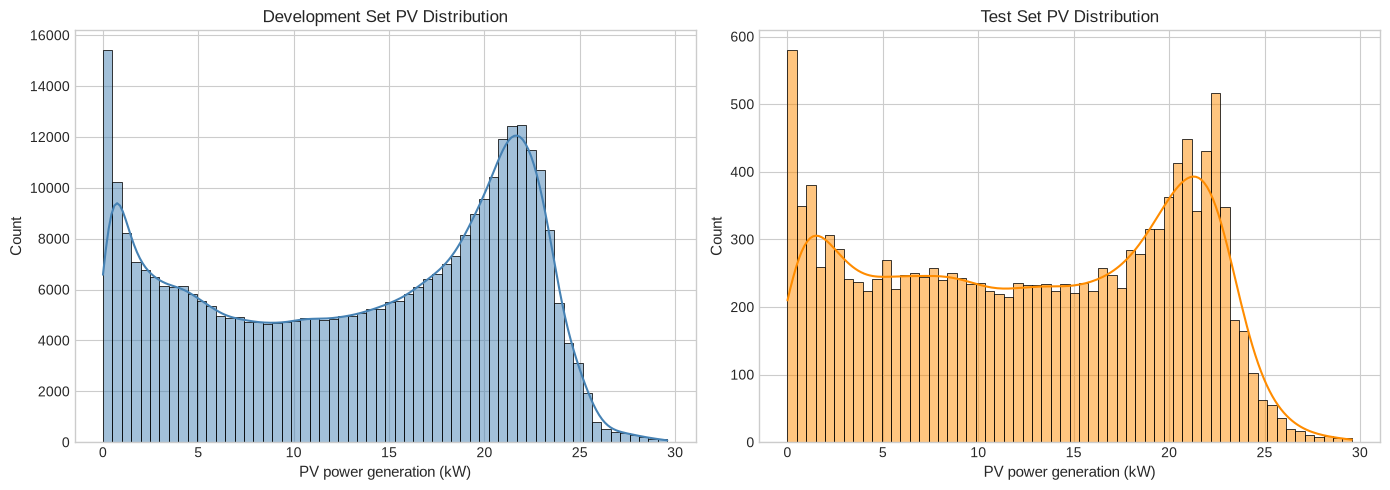

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(trainval_pv.flatten(), bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Development Set PV Distribution")
axes[0].set_xlabel("PV power generation (kW)")
axes[0].set_ylabel("Count")

sns.histplot(test_pv.flatten(), bins=60, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Test Set PV Distribution")
axes[1].set_xlabel("PV power generation (kW)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [7]:
zero_thresh = 0.05  # kW

for name, pv_arr in [("Train/Val", trainval_pv), ("Test", test_pv)]:
    pv_flat = pv_arr.flatten()
    n_zero = np.sum(pv_flat <= zero_thresh)
    print(
        f"{name}: {n_zero} / {len(pv_flat)} samples "
        f"({100*n_zero/len(pv_flat):.2f}%) at/near zero (<= {zero_thresh} kW)"
    )

Train/Val: 1509 / 349372 samples (0.43%) at/near zero (<= 0.05 kW)
Test: 55 / 14003 samples (0.39%) at/near zero (<= 0.05 kW)


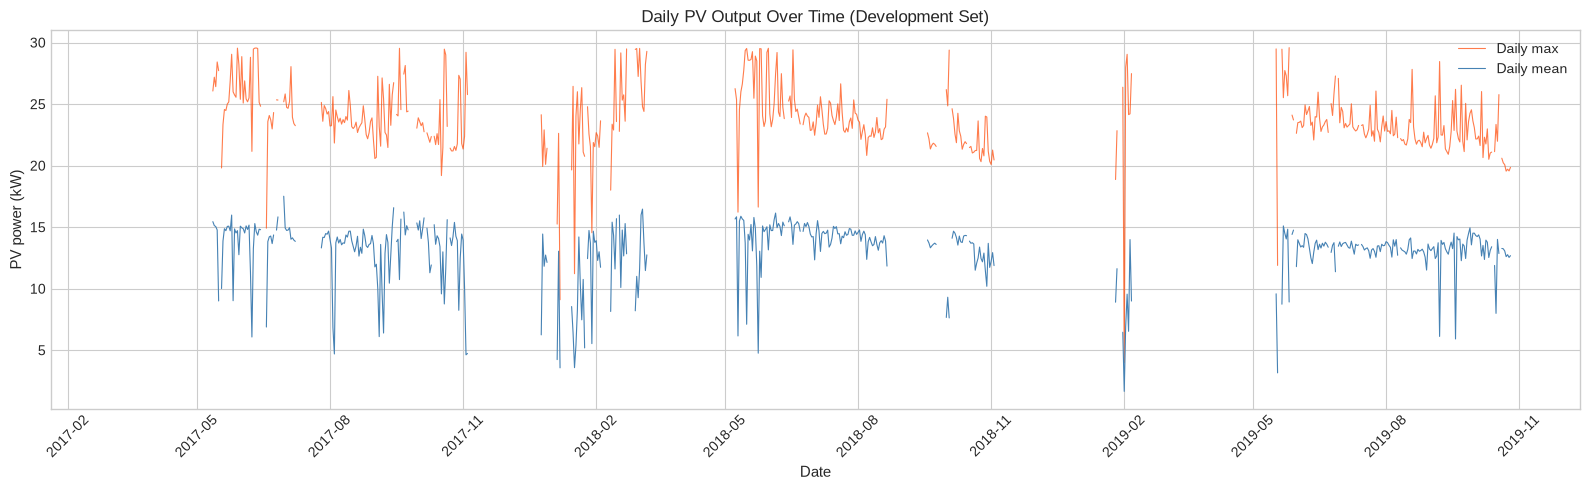

In [8]:
if trainval_times is not None:
    df_trainval = pd.DataFrame(
        {"timestamp": trainval_times, "pv": trainval_pv.flatten()}
    ).set_index("timestamp")

    # Daily mean/max for a readable long-range view
    daily = df_trainval["pv"].resample("D").agg(["mean", "max"])

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(
        daily.index,
        daily["max"],
        label="Daily max",
        color="orangered",
        alpha=0.7,
        linewidth=0.8,
    )
    ax.plot(
        daily.index, daily["mean"], label="Daily mean", color="steelblue", linewidth=0.8
    )
    ax.set_title("Daily PV Output Over Time (Development Set)")
    ax.set_xlabel("Date")
    ax.set_ylabel("PV power (kW)")
    ax.legend()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

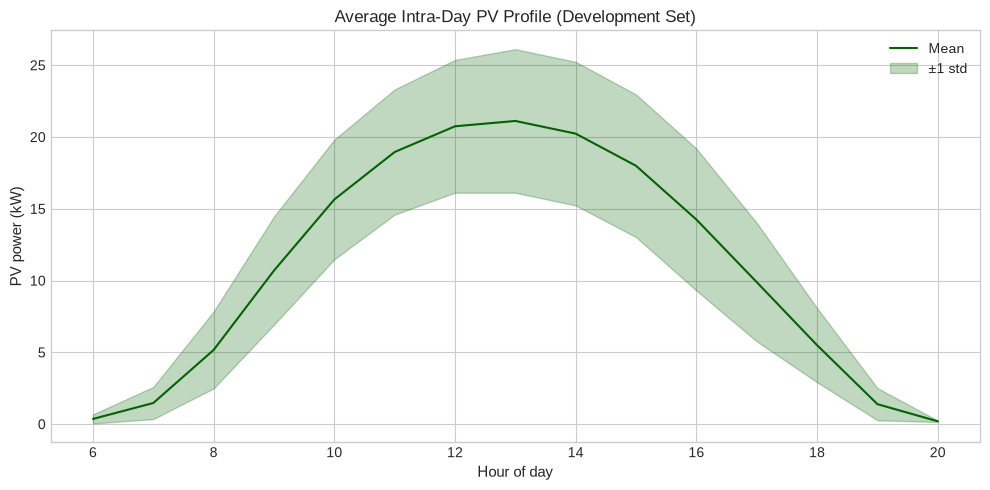

In [9]:
if trainval_times is not None:
    df_trainval["hour"] = df_trainval.index.hour + df_trainval.index.minute / 60

    hourly_stats = df_trainval.groupby(df_trainval.index.hour)["pv"].agg(
        ["mean", "std", "min", "max"]
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(hourly_stats.index, hourly_stats["mean"], color="darkgreen", label="Mean")
    ax.fill_between(
        hourly_stats.index,
        hourly_stats["mean"] - hourly_stats["std"],
        hourly_stats["mean"] + hourly_stats["std"],
        alpha=0.25,
        color="darkgreen",
        label="±1 std",
    )
    ax.set_title("Average Intra-Day PV Profile (Development Set)")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("PV power (kW)")
    ax.legend()
    plt.tight_layout()
    plt.show()

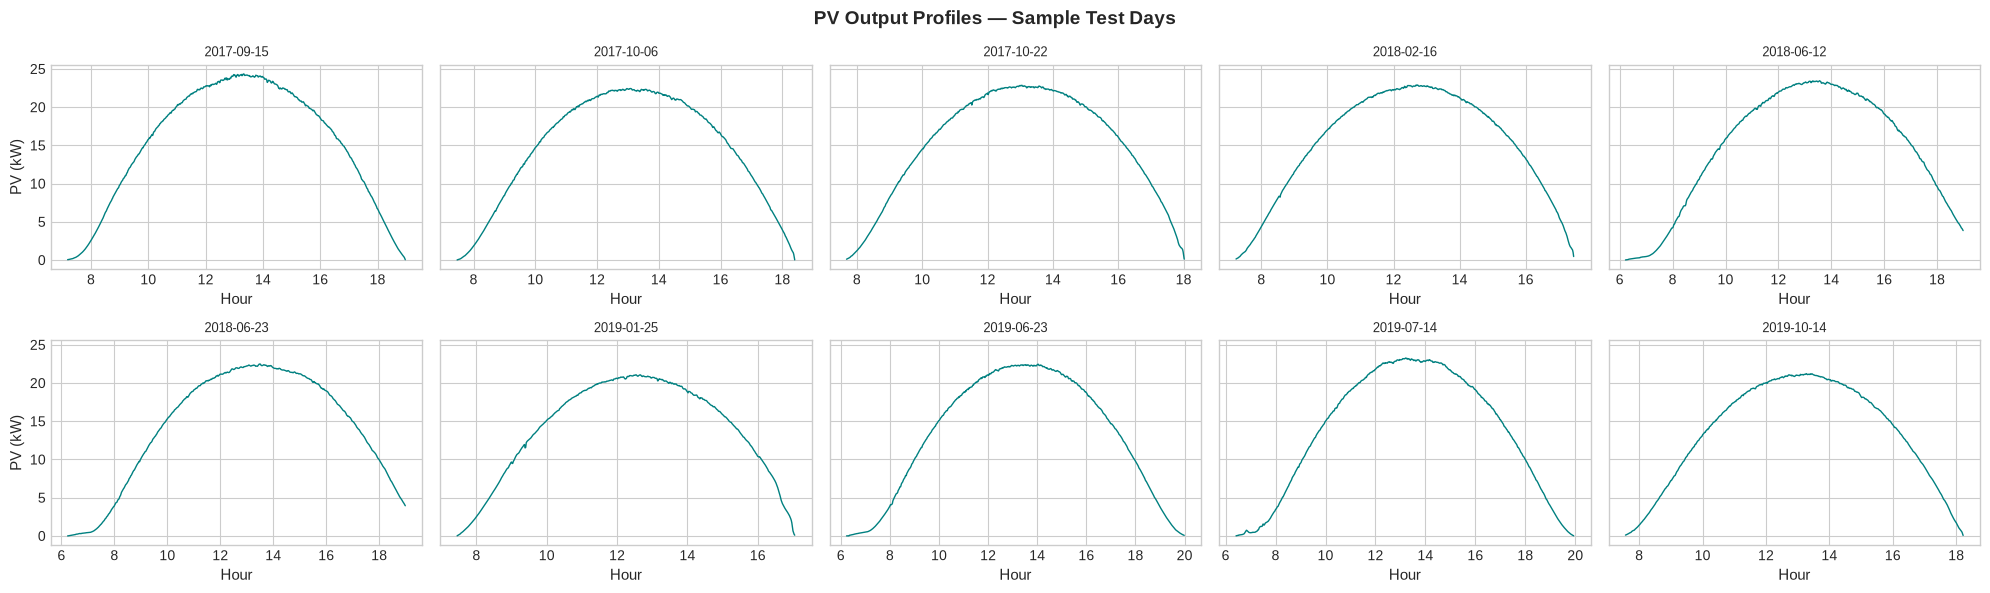

In [10]:
if test_times is not None:
    df_test = pd.DataFrame({"timestamp": test_times, "pv": test_pv.flatten()})
    df_test["date"] = df_test["timestamp"].dt.date

    unique_days = df_test["date"].unique()
    n_show = min(10, len(unique_days))

    fig, axes = plt.subplots(2, 5, figsize=(20, 6), sharey=True)
    axes = axes.flatten()

    for i, day in enumerate(unique_days[:n_show]):
        day_data = df_test[df_test["date"] == day]
        axes[i].plot(
            day_data["timestamp"].dt.hour + day_data["timestamp"].dt.minute / 60,
            day_data["pv"],
            color="teal",
            linewidth=1,
        )
        axes[i].set_title(str(day), fontsize=9)
        axes[i].set_xlabel("Hour")
        if i % 5 == 0:
            axes[i].set_ylabel("PV (kW)")

    fig.suptitle(
        "PV Output Profiles — Sample Test Days", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

PV 15-min rolling std — summary (proxy for short-term variability/cloudiness):
count    349368.000000
mean          0.646638
std           1.074284
min           0.000000
25%           0.176376
50%           0.337843
75%           0.499956
max          11.277281
Name: pv, dtype: float64


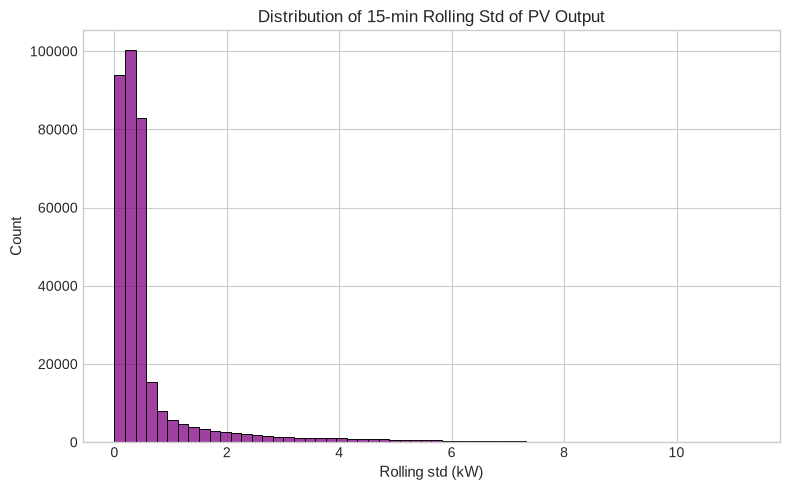

In [11]:
if trainval_times is not None:
    df_trainval_sorted = df_trainval.sort_index()
    rolling_std = df_trainval_sorted["pv"].rolling(window=15, min_periods=5).std()

    print(
        "PV 15-min rolling std — summary (proxy for short-term variability/cloudiness):"
    )
    print(rolling_std.describe())

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(rolling_std.dropna(), bins=60, ax=ax, color="purple")
    ax.set_title("Distribution of 15-min Rolling Std of PV Output")
    ax.set_xlabel("Rolling std (kW)")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1161394/499094936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


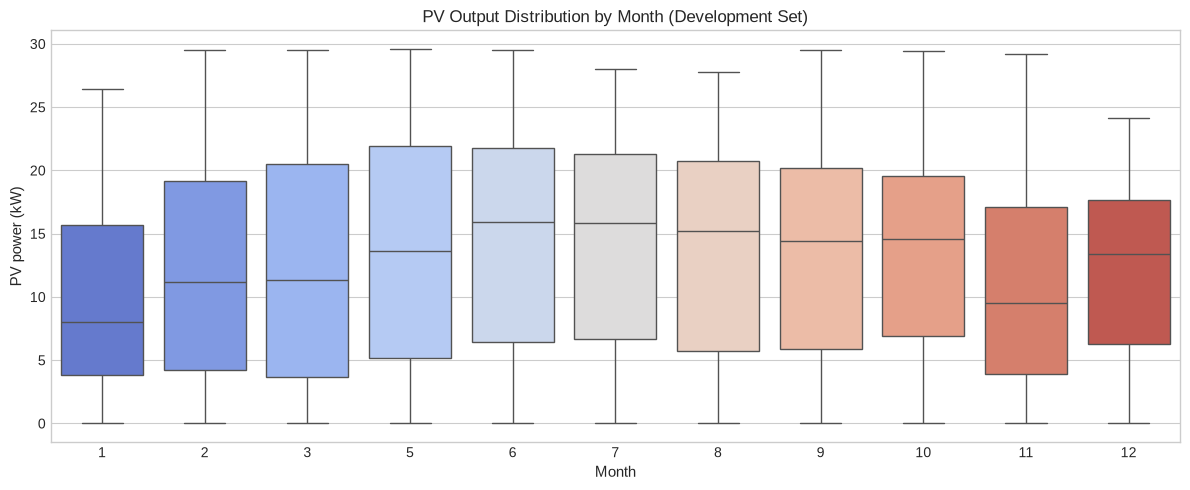

In [12]:
if trainval_times is not None:
    df_trainval_sorted["month"] = df_trainval_sorted.index.month

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        x="month",
        y="pv",
        data=df_trainval_sorted.reset_index(),
        ax=ax,
        showfliers=False,
        palette="coolwarm",
    )
    ax.set_title("PV Output Distribution by Month (Development Set)")
    ax.set_xlabel("Month")
    ax.set_ylabel("PV power (kW)")
    plt.tight_layout()
    plt.show()